# Exploratory Data Analysis

**Project:** Concrete Strength Prediction - Team 6

**Team:** Abel Berta, Markel Gregory

**Date:** 02/22/2026




## Table of Contents
1. Setup & Load Data
2. Data Quality Check
3. Target Variable Analysis
4. Feature Distributions
5. Correlation Analysis
6. Key Findings Summary



## 1. Setup & Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
pd.set_option('display.max_columns', None)

print("✓ Libraries loaded!")

✓ Libraries loaded!


In [ ]:
df = pd.read_csv(r"C:\Users\otfxa\Documents\GitHub\Team6-R3ConcreteStrengthPrediction\data\raw\Concrete_Data.csv")

In [ ]:
df.shape
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1030 entries, 0 to 1029
Data columns (total 9 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              1030 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  1030 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             1030 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              1030 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    1030 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   1030 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      1030 non-null   float64
 7   Age (day)                                              1030 non-null   int64  
 8   Concrete compressive strength(MPa, megapascals)  

,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000



## 2. Data Quality Check

**What are the data types?**
I see that my dataset has 9 columns total: 8 of them are float64 (all the mixture ingredients plus concrete strength) and 1 is int64 (Age (day)).

**Are there missing values?**
There are no missing values and no duplicate rows, so basic data completeness looks very good.

A**re there duplicate rows?**
When running df.duplicated().sum(), the response is 0, so we can conclude that there are no duplicate rows in my dataset.



## 3. Target Variable Analysis

**Your target variable:** We are trying to predict concrete compressive strength (in MPa, megapascals) for each concrete mix

Cleaned columns:
'Cement (component 1)(kg in a m^3 mixture)'
'Blast Furnace Slag (component 2)(kg in a m^3 mixture)'
'Fly Ash (component 3)(kg in a m^3 mixture)'
'Water  (component 4)(kg in a m^3 mixture)'
'Superplasticizer (component 5)(kg in a m^3 mixture)'
'Coarse Aggregate  (component 6)(kg in a m^3 mixture)'
'Fine Aggregate (component 7)(kg in a m^3 mixture)'
'Age (day)'
'Concrete compressive strength(MPa, megapascals)'
count    1030.000000
mean       35.817961
std        16.705742
min         2.330000
25%        23.710000
50%        34.445000
75%        46.135000
max        82.600000
Name: Concrete compressive strength(MPa, megapascals), dtype: float64

Min: 2.33 MPa
Max: 82.60 MPa
Mean: 35.82 MPa
Median: 34.45 MPa


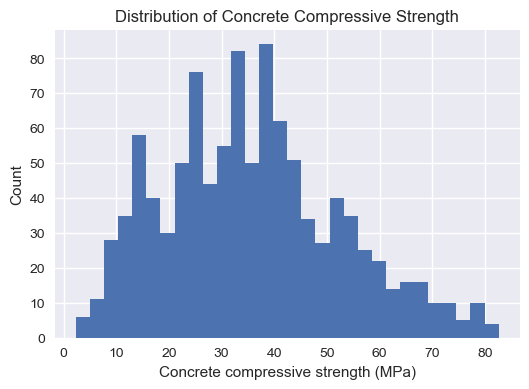

In [ ]:
df.columns = df.columns.str.strip()

print("Cleaned columns:")
for col in df.columns:
    print(repr(col))

import matplotlib.pyplot as plt

target = 'Concrete compressive strength(MPa, megapascals)'

summary = df[target].describe()
print(summary)

target_min = summary['min']
target_max = summary['max']
target_mean = summary['mean']
target_median = df[target].median()

print(f"\nMin: {target_min:.2f} MPa")
print(f"Max: {target_max:.2f} MPa")
print(f"Mean: {target_mean:.2f} MPa")
print(f"Median: {target_median:.2f} MPa")

# Histogram
plt.figure(figsize=(6,4))
df[target].hist(bins=30)
plt.xlabel('Concrete compressive strength (MPa)')
plt.ylabel('Count')
plt.title('Distribution of Concrete Compressive Strength')
plt.show()


### Target Variable Observations

**Distribution shape:** Concrete compressive strength ranges from 2.33 to 82.60 MPa, with a mean of 35.82 MPa and a median of 34.45 MPa, so the distribution is mildly right‑skewed.

**Outliers:** The histogram shows only a few very low‑strength mixes near 2–5 MPa and a few very high‑strength mixes above about 70 MPa that look like potential outliers.

**Potential issues:** The mild skew and extreme values could affect models that assume symmetric errors, so we may later consider transformations or robust methods.



## 4. Feature Distributions


=== Cement (component 1)(kg in a m^3 mixture) ===
count    1030.000000
mean      281.167864
std       104.506364
min       102.000000
25%       192.375000
50%       272.900000
75%       350.000000
max       540.000000
Name: Cement (component 1)(kg in a m^3 mixture), dtype: float64


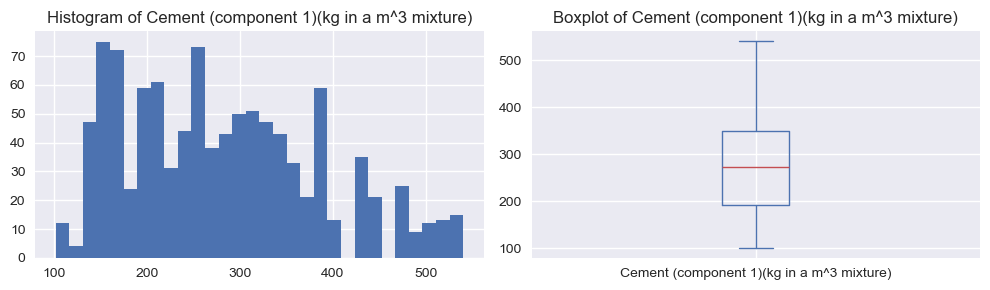


=== Blast Furnace Slag (component 2)(kg in a m^3 mixture) ===
count    1030.000000
mean       73.895825
std        86.279342
min         0.000000
25%         0.000000
50%        22.000000
75%       142.950000
max       359.400000
Name: Blast Furnace Slag (component 2)(kg in a m^3 mixture), dtype: float64


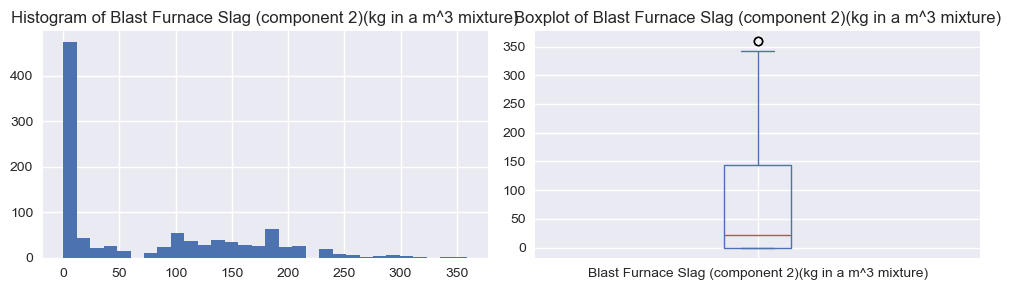


=== Fly Ash (component 3)(kg in a m^3 mixture) ===
count    1030.000000
mean       54.188350
std        63.997004
min         0.000000
25%         0.000000
50%         0.000000
75%       118.300000
max       200.100000
Name: Fly Ash (component 3)(kg in a m^3 mixture), dtype: float64


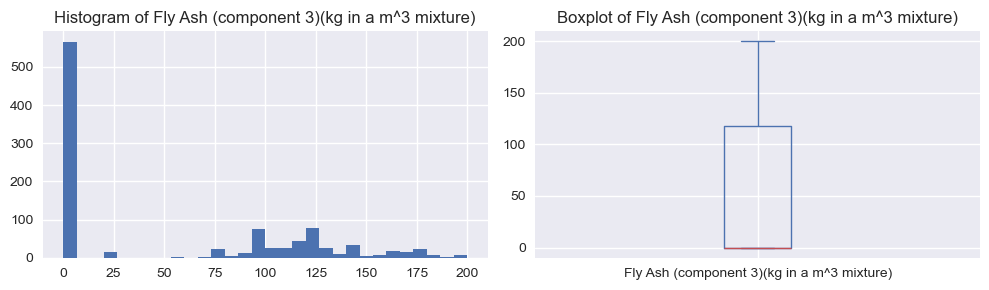


=== Water  (component 4)(kg in a m^3 mixture) ===
count    1030.000000
mean      181.567282
std        21.354219
min       121.800000
25%       164.900000
50%       185.000000
75%       192.000000
max       247.000000
Name: Water  (component 4)(kg in a m^3 mixture), dtype: float64


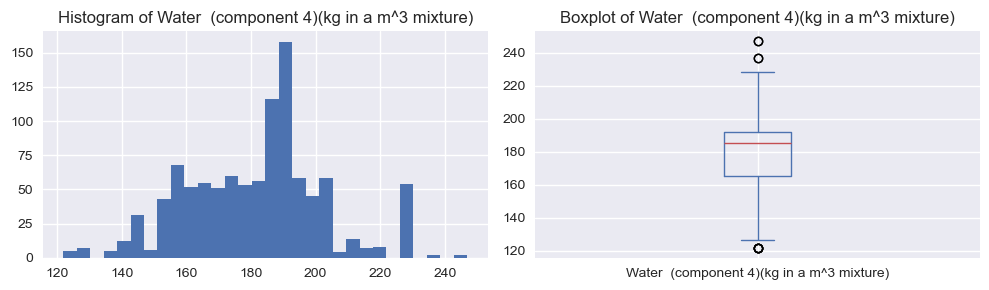


=== Superplasticizer (component 5)(kg in a m^3 mixture) ===
count    1030.000000
mean        6.204660
std         5.973841
min         0.000000
25%         0.000000
50%         6.400000
75%        10.200000
max        32.200000
Name: Superplasticizer (component 5)(kg in a m^3 mixture), dtype: float64


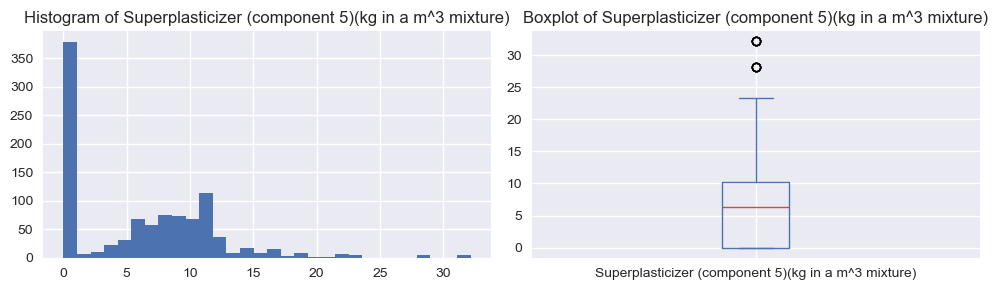


=== Coarse Aggregate  (component 6)(kg in a m^3 mixture) ===
count    1030.000000
mean      972.918932
std        77.753954
min       801.000000
25%       932.000000
50%       968.000000
75%      1029.400000
max      1145.000000
Name: Coarse Aggregate  (component 6)(kg in a m^3 mixture), dtype: float64


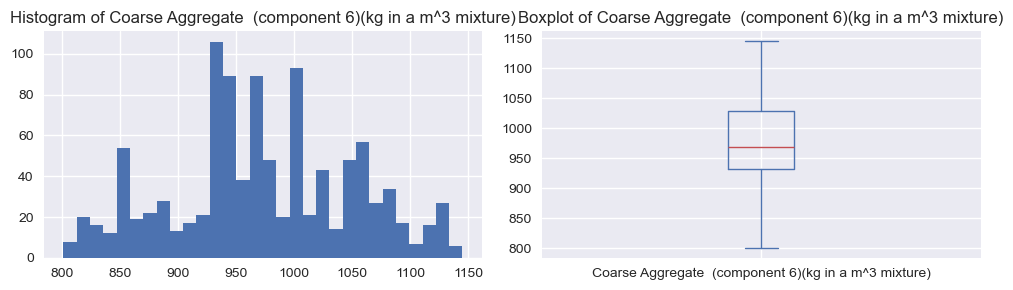


=== Fine Aggregate (component 7)(kg in a m^3 mixture) ===
count    1030.000000
mean      773.580485
std        80.175980
min       594.000000
25%       730.950000
50%       779.500000
75%       824.000000
max       992.600000
Name: Fine Aggregate (component 7)(kg in a m^3 mixture), dtype: float64


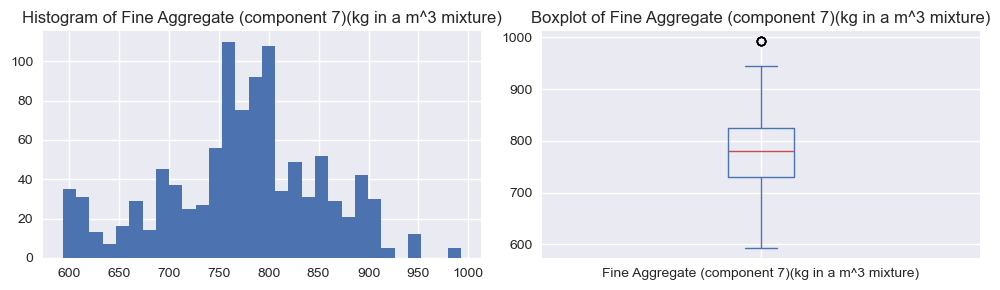


=== Age (day) ===
count    1030.000000
mean       45.662136
std        63.169912
min         1.000000
25%         7.000000
50%        28.000000
75%        56.000000
max       365.000000
Name: Age (day), dtype: float64


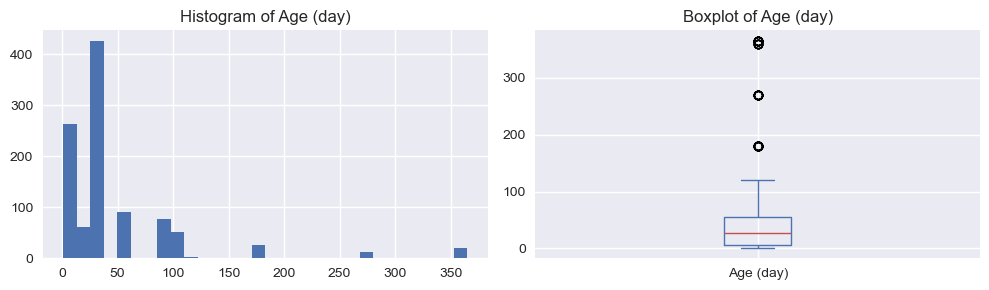

In [ ]:
numeric_features = [
    'Cement (component 1)(kg in a m^3 mixture)',
    'Blast Furnace Slag (component 2)(kg in a m^3 mixture)',
    'Fly Ash (component 3)(kg in a m^3 mixture)',
    'Water  (component 4)(kg in a m^3 mixture)',
    'Superplasticizer (component 5)(kg in a m^3 mixture)',
    'Coarse Aggregate  (component 6)(kg in a m^3 mixture)',
    'Fine Aggregate (component 7)(kg in a m^3 mixture)',
    'Age (day)'
]
for col in numeric_features:
    print(f"\n=== {col} ===")
    print(df[col].describe())

    plt.figure(figsize=(10,3))

    # Histogram
    plt.subplot(1,2,1)
    df[col].hist(bins=30)
    plt.title(f'Histogram of {col}')

    # Box plot
    plt.subplot(1,2,2)
    df[col].plot(kind='box')
    plt.title(f'Boxplot of {col}')

    plt.tight_layout()
    plt.show()

### Feature Distribution Observations

**Distributions:** Several ingredients, including slag, fly ash, superplasticizer, and age, are strongly right‑skewed, with many zeros or small values and long tails to large values, while cement and the aggregates are more spread out across their ranges.

**Outliers:** Box plots show clear high‑end outliers for slag (values near 359.4 kg/m³), superplasticizer (up to 32.2 kg/m³), and age (up to 365 days), compared with much lower medians.
​

**Scale differences:** Features are on very different scales—for example, coarse aggregate averages about 973 kg/m³, while superplasticizer averages only 6.20 kg/m³—so standardization or scaling will likely be helpful for many models



## 5. Correlation Analysis

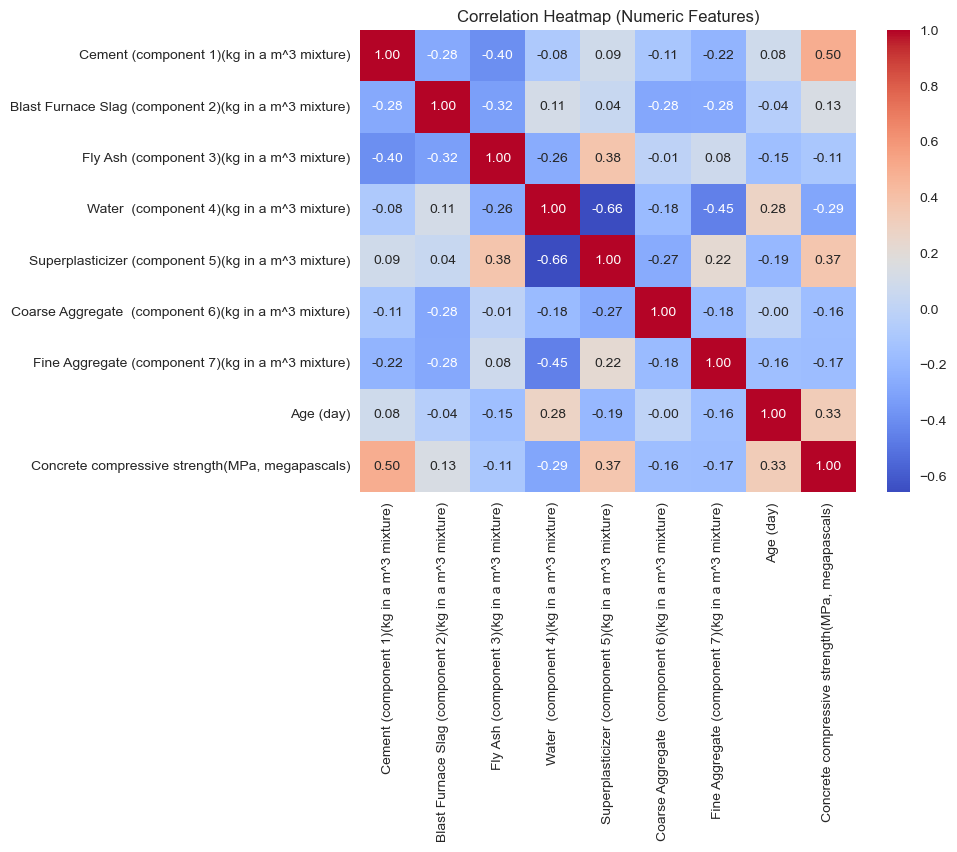

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()

### Correlation Observations


**Strongest predictor:** Cement has the strongest linear relationship with strength, with a correlation of about r ≈ 0.50 to the target.

**Other important features:** Superplasticizer (r ≈ 0.37) and age (r ≈ 0.33) are also positively correlated with strength, while water has a moderate negative correlation around r ≈ −0.29, consistent with lower water–cement ratios giving stronger concrete.

**Multicollinearity concerns:** Water and superplasticizer are fairly strongly negatively correlated (r ≈ −0.66), and slag, fly ash, and aggregates show moderate correlations with other ingredients, which could introduce multicollinearity for linear models.


## 6. Key Findings Summary

**Dataset:** The dataset contains 1,030 concrete mixes and 9 variables, all numeric, with no missing values and no duplicates.

**Target behavior:** Concrete compressive strength ranges from 2.33 to 82.60 MPa with a mean of 35.82 MPa and median of 34.45 MPa, giving a mildly right‑skewed distribution.

**Strongest predictors:** Cement is the strongest single predictor of strength (r ≈ 0.50), followed by superplasticizer (r ≈ 0.37) and age (r ≈ 0.33), while water is negatively related to strength (r ≈ −0.29).

**Outliers and skew:** Slag, fly ash, superplasticizer, and age all show right‑skewed distributions with notable high‑end outliers, such as age up to 365 days versus a median of 28 days.

**Feature scales and correlations:** Ingredients live on very different scales (for example, aggregates near 1,000 kg/m³ vs. superplasticizer near 6 kg/m³ on average) and some pairs like water–superplasticizer show strong correlations, suggesting the need for scaling and attention to multicollinearity in modeling

## EDA Checklist

Before moving to modeling, ensure you've completed:

- [ ] Loaded and examined the data
- [ ] Checked data types
- [ ] Identified and documented missing values
- [ ] Analyzed target variable distribution
- [ ] Examined feature distributions
- [ ] Created correlation analysis
- [ ] Documented key findings
- [ ] Identified potential data quality issues